In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
ratings_dataframe = pd.read_csv('ratings.csv')
movies_dataframe = pd.read_csv('movies.csv')
number_users = ratings_dataframe['userId'].nunique()
number_movies = ratings_dataframe['movieId'].nunique()
number_ratings = len(ratings_dataframe)
all_possible_pairs = number_users * number_movies
sparsity = 1.0 - (number_ratings / all_possible_pairs)
print(f"Number of unique users:  {number_users}")
print(f"Number of unique movies: {number_movies}")
print(f"Total number of ratings: {number_ratings}")
print(f"Matrix Sparsity:         {sparsity:.4%} (fraction unrated)")
rating_matrix = ratings_dataframe.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
)

Number of unique users:  610
Number of unique movies: 9724
Total number of ratings: 100836
Matrix Sparsity:         98.3000% (fraction unrated)


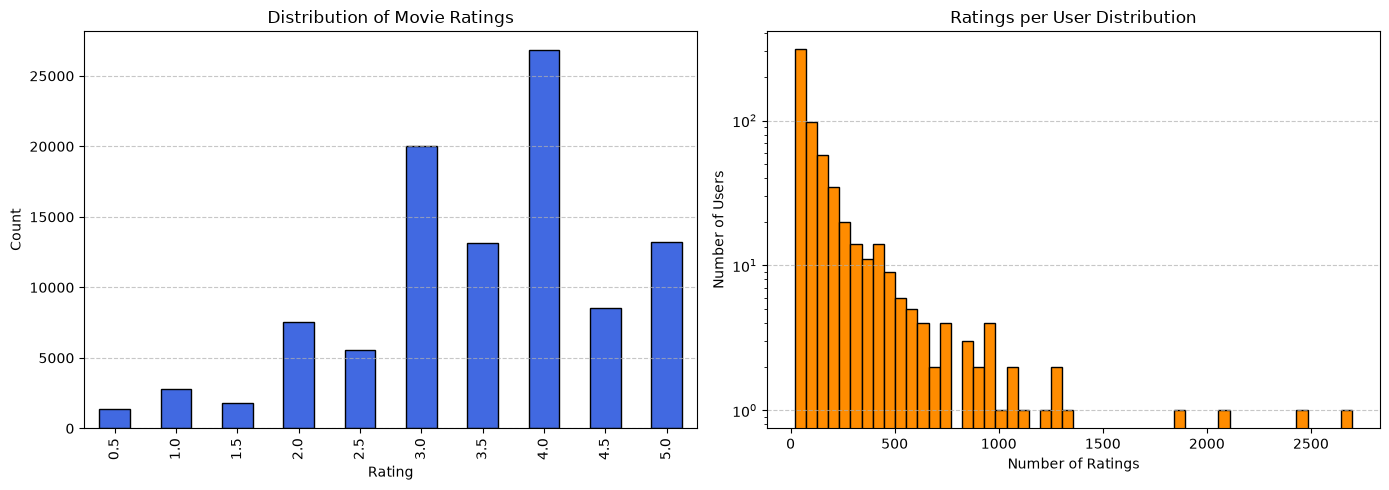

In [ ]:
#ai genrated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of ratings
ratings_dataframe['rating'].value_counts().sort_index().plot(
    kind='bar', 
    ax=axes[0], 
    color='royalblue', 
    edgecolor='black'
)
axes[0].set_title('Distribution of Movie Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# (b) Distribution of ratings given per user
ratings_per_user = ratings_dataframe.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Ratings per User Distribution')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_yscale('log')  # Log scale highlights heavy-tail distribution
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
#end of ai

In [ ]:
def get_co_rated(matrix: pd.DataFrame, a, b, axis: str = "index"):
    if axis == "index":
        vec_a = matrix.loc[a]
        vec_b = matrix.loc[b]
    elif axis == "columns":
        vec_a = matrix[a]
        vec_b = matrix[b]
    else:
        raise ValueError("axis must be either 'index' or 'columns'")
    common_mask = vec_a.notna() & vec_b.notna()
    return vec_a[common_mask].to_numpy(dtype=float), vec_b[common_mask].to_numpy(dtype=float)
    
def euclidean_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    
    diff = vec1 - vec2
    dist = np.sqrt(np.dot(diff, diff))
    return 1.0 / (1.0 + dist)

def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0
    
    return float(np.dot(vec1, vec2) / (norm1 * norm2))

def pearson_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    centered_1 = vec1 - np.mean(vec1)
    centered_2 = vec2 - np.mean(vec2)
    norm1 = np.linalg.norm(centered_1)
    norm2 = np.linalg.norm(centered_2)
    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0
    return float(np.dot(centered_1, centered_2) / (norm1 * norm2))

In [ ]:
#used for test will be removed
toy_a = np.array([5.0, 4.0, 5.0, 3.0])
toy_b = np.array([3.0, 2.0, 3.0, 1.0])

diff = toy_a - toy_b
raw_euclidean_dist = np.sqrt(np.dot(diff, diff))
euc_sim = euclidean_similarity(toy_a, toy_b)
cos_sim = cosine_similarity(toy_a, toy_b)
pea_sim = pearson_similarity(toy_a, toy_b)

print("--- Sanity Check: Section 3.2 Worked Example ---")
print(f"Raw Euclidean Distance : {raw_euclidean_dist:.4f}  (Expected: 4.0)")
print(f"Euclidean Similarity   : {euc_sim:.4f}            (1 / (1 + 4) = 0.2000)")
print(f"Cosine Similarity      : {cos_sim:.3f}             (Expected: ~0.987)")
print(f"Pearson Correlation    : {pea_sim:.1f}             (Expected: 1.0)")


--- Sanity Check: Section 3.2 Worked Example ---
Raw Euclidean Distance : 4.0000  (Expected: 4.0)
Euclidean Similarity   : 0.2000            (1 / (1 + 4) = 0.2000)
Cosine Similarity      : 0.987             (Expected: ~0.987)
Pearson Correlation    : 1.0             (Expected: 1.0)
